# Fine-tuned VideoMAE — post-training analysis

This notebook reads Hugging Face `Trainer` logs under a run directory (e.g. `checkpoints/videomae-workout`), plots learning curves, and (optionally) runs test-set **F1** and **inference timing** using the same data path as `scripts/eval.py`.

**Configure** `RUN_DIR` below to point at your checkpoint folder (the directory that contains `config.json` and `checkpoint-*` subfolders).

In [ ]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Repo root (parent of this notebook's folder)
REPO_ROOT = Path.cwd()
if (REPO_ROOT / "analysis").is_dir() and (REPO_ROOT / "utils").is_dir():
    pass
elif (REPO_ROOT.parent / "utils").is_dir():
    REPO_ROOT = REPO_ROOT.parent
sys.path.insert(0, str(REPO_ROOT))

from analysis.training_history import (
    load_train_results_json,
    load_training_history,
    moving_average,
    resolve_trainer_state_path,
)

## Video-MAE trained on Recorded Data

Run directory: /home/ec2-user/workout-prediction/checkpoints/videomae-youtube


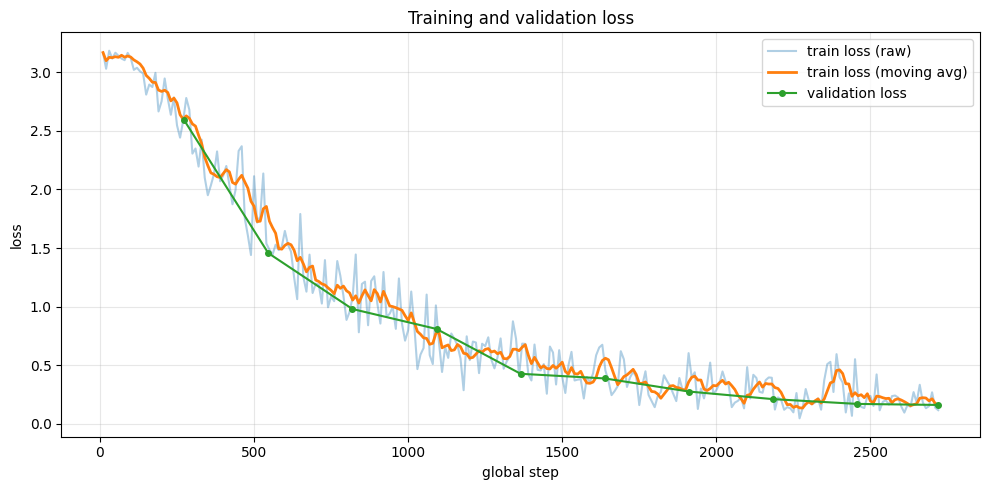

{
  "best_global_step": 2457,
  "best_metric": 0.9469026548672567,
  "best_model_checkpoint": "checkpoints/videomae-youtube/checkpoint-2457",
  "global_step": 2720,
  "epoch": 9.963369963369964,
  "trainer_state_path": "/home/ec2-user/workout-prediction/checkpoints/videomae-youtube/checkpoint-2720/trainer_state.json"
}


Test inference: 100%|██████████| 61/61 [00:53<00:00,  1.14sample/s, phase=timed]

Test samples: 59
Accuracy:     0.7119
F1 macro:     0.6392
F1 weighted:  0.6844
Wall ms/sample (inference only): 15.49
Throughput:   64.548 samples/s

                     precision    recall  f1-score   support

barbell biceps curl       0.00      0.00      0.00         0
        bench press       0.40      0.67      0.50         3
  chest fly machine       1.00      0.75      0.86         4
           deadlift       0.00      0.00      0.00         2
decline bench press       0.33      0.67      0.44         3
        hammer curl       0.50      0.67      0.57         3
         hip thrust       0.60      1.00      0.75         3
incline bench press       0.00      0.00      0.00         3
       lat pulldown       0.50      0.33      0.40         3
      lateral raise       1.00      0.50      0.67         2
      leg extension       0.75      1.00      0.86         3
         leg raises       1.00      1.00      1.00         3
              plank       1.00      1.00      1.00     

In [8]:
# VideoMAE YouTube run (change as needed)
RUN_DIR = REPO_ROOT / "checkpoints" / "videomae-youtube" # change here for the model to be analyzed
print("Run directory:", RUN_DIR.resolve())

ts_path = resolve_trainer_state_path(RUN_DIR)
history = load_training_history(trainer_state_path=ts_path)

train_df = pd.DataFrame(history.train)
eval_df = pd.DataFrame(history.eval)

fig, ax = plt.subplots(figsize=(10, 5))
if not train_df.empty and "loss" in train_df.columns:
    ax.plot(train_df["step"], train_df["loss"], alpha=0.35, label="train loss (raw)")
    if len(train_df) > 5:
        sm = moving_average(train_df["loss"].tolist(), window=max(5, len(train_df) // 50))
        ax.plot(train_df["step"], sm, linewidth=2, label="train loss (moving avg)")
if not eval_df.empty and "eval_loss" in eval_df.columns:
    ax.plot(eval_df["step"], eval_df["eval_loss"], "o-", markersize=4, label="validation loss")
ax.set_xlabel("global step")
ax.set_ylabel("loss")
ax.set_title("Training and validation loss")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(json.dumps(history.trainer_meta, indent=2))

from analysis.inference_metrics import evaluate_checkpoint_on_test

# Saved model directory (same as: python scripts/eval.py --checkpoint …)
CHECKPOINT = RUN_DIR

# Default batch_size=1: one clip per tqdm step (unit: sample). Use batch_size=4+ for speed (unit: batch).
result = evaluate_checkpoint_on_test(
    checkpoint=CHECKPOINT,
    batch_size=1,
    warmup_batches=2,
    show_progress=True,
)
print(f"Test samples: {result.n_samples}")
print(f"Accuracy:     {result.accuracy:.4f}")
print(f"F1 macro:     {result.f1_macro:.4f}")
print(f"F1 weighted:  {result.f1_weighted:.4f}")
print(f"Wall ms/sample (inference only): {result.wall_time_per_sample_s * 1000:.2f}")
print(f"Throughput:   {result.throughput_samples_per_s:.3f} samples/s")
print("\n" + result.classification_report)

## Video-MAE trained on Recorded and Youtube Data

Run directory: /home/ec2-user/workout-prediction/checkpoints/videomae-youtube


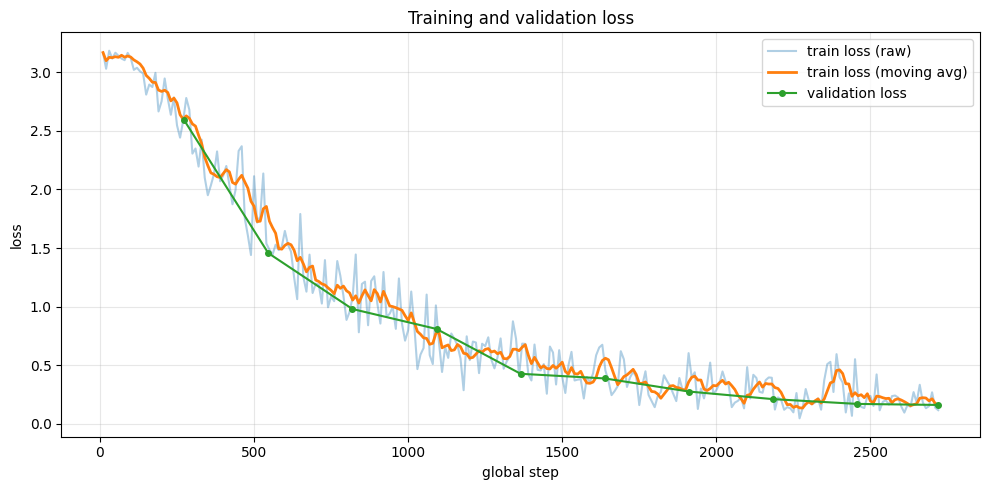

{
  "best_global_step": 2457,
  "best_metric": 0.9469026548672567,
  "best_model_checkpoint": "checkpoints/videomae-youtube/checkpoint-2457",
  "global_step": 2720,
  "epoch": 9.963369963369964,
  "trainer_state_path": "/home/ec2-user/workout-prediction/checkpoints/videomae-youtube/checkpoint-2720/trainer_state.json"
}


Test inference: 100%|██████████| 61/61 [00:53<00:00,  1.14sample/s, phase=timed]

Test samples: 59
Accuracy:     0.7119
F1 macro:     0.6392
F1 weighted:  0.6844
Wall ms/sample (inference only): 15.50
Throughput:   64.518 samples/s

                     precision    recall  f1-score   support

barbell biceps curl       0.00      0.00      0.00         0
        bench press       0.40      0.67      0.50         3
  chest fly machine       1.00      0.75      0.86         4
           deadlift       0.00      0.00      0.00         2
decline bench press       0.33      0.67      0.44         3
        hammer curl       0.50      0.67      0.57         3
         hip thrust       0.60      1.00      0.75         3
incline bench press       0.00      0.00      0.00         3
       lat pulldown       0.50      0.33      0.40         3
      lateral raise       1.00      0.50      0.67         2
      leg extension       0.75      1.00      0.86         3
         leg raises       1.00      1.00      1.00         3
              plank       1.00      1.00      1.00     

In [7]:
# VideoMAE YouTube run (change as needed)
RUN_DIR = REPO_ROOT / "checkpoints" / "videomae-youtube" # change here for the model to be analyzed
print("Run directory:", RUN_DIR.resolve())

ts_path = resolve_trainer_state_path(RUN_DIR)
history = load_training_history(trainer_state_path=ts_path)

train_df = pd.DataFrame(history.train)
eval_df = pd.DataFrame(history.eval)

fig, ax = plt.subplots(figsize=(10, 5))
if not train_df.empty and "loss" in train_df.columns:
    ax.plot(train_df["step"], train_df["loss"], alpha=0.35, label="train loss (raw)")
    if len(train_df) > 5:
        sm = moving_average(train_df["loss"].tolist(), window=max(5, len(train_df) // 50))
        ax.plot(train_df["step"], sm, linewidth=2, label="train loss (moving avg)")
if not eval_df.empty and "eval_loss" in eval_df.columns:
    ax.plot(eval_df["step"], eval_df["eval_loss"], "o-", markersize=4, label="validation loss")
ax.set_xlabel("global step")
ax.set_ylabel("loss")
ax.set_title("Training and validation loss")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(json.dumps(history.trainer_meta, indent=2))

from analysis.inference_metrics import evaluate_checkpoint_on_test

# Saved model directory (same as: python scripts/eval.py --checkpoint …)
CHECKPOINT = RUN_DIR

# Default batch_size=1: one clip per tqdm step (unit: sample). Use batch_size=4+ for speed (unit: batch).
result = evaluate_checkpoint_on_test(
    checkpoint=CHECKPOINT,
    batch_size=1,
    warmup_batches=2,
    show_progress=True,
)
print(f"Test samples: {result.n_samples}")
print(f"Accuracy:     {result.accuracy:.4f}")
print(f"F1 macro:     {result.f1_macro:.4f}")
print(f"F1 weighted:  {result.f1_weighted:.4f}")
print(f"Wall ms/sample (inference only): {result.wall_time_per_sample_s * 1000:.2f}")
print(f"Throughput:   {result.throughput_samples_per_s:.3f} samples/s")
print("\n" + result.classification_report)